In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import time

In [3]:
class LinearRegression:

    def __init__(self, weight=0.0, bias=0.0, learning_rate=0.01, batch=100, epochs=5):
        self.weight = weight
        self.bias = bias
        self.learning_rate =learning_rate
        self.batch = batch
        self.epochs = epochs

        # Loss History
        self.loss = []

        # Plot parameters (Figure, Axes)
        self.fig, (self.model, self.err) = plt.subplots(1, 2, figsize=(10, 5))

    def get_parameters(self):
        return f"""Weight: {self.weight}
Bias: {self.bias}
Learning rate: {self.learning_rate}
Batch: {self.batch}
Epochs: {self.epochs} """
    
    def train(self, feature, label, show_graph=False, final_graph=False):
        batch_x = np.array_split(feature, (feature.__len__()/self.batch))
        batch_y = np.array_split(label, (label.__len__()/self.batch))

        for epoch in range(0, self.epochs):

            for i in range(0, batch_x.__len__()):
                x = batch_x[i]
                y = batch_y[i]

                n = x.__len__()

                # Forward pass
                y_pred = self.weight * x + self.bias

                # Calculate loss
                loss = self._calculate_loss(y, y_pred)

                dw = (-2/n) * np.sum(x * (y - y_pred))
                db = (-2/n) * np.sum(y - y_pred)

                # Update parameters
                self.weight -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

                self.loss.append(loss)

                if(show_graph):
                    self._plot_graph([feature, label], [x, (self.weight * x) + self.bias])

        if(final_graph): self._final_graph(feature, label)
        else: self.fig.clear() # clear the empty figure (default)
    
    def _calculate_loss(self, actual_var, predicted_var):
        n = actual_var.__len__()
        mse = (1/n) * np.sum((actual_var - predicted_var) ** 2)

        return mse
    
    def predict(self, x):
        return self.weight * x + self.bias

    def _plot_graph(self, data_set, predicted):
            [feature, label] = data_set
            self.model.scatter(x=feature, y=label, s=15, label='Dataset')

            [x, y] = predicted
            self.model.plot(x, y, label='Regression Line', color='red')

            self.model.set_ylim(top=140)
            self.model.set_xlim(right=20)

            self.err.plot(self.loss, label='Training Loss', color='blue')

            self.model.set_title("Model Line")
            self.model.set_xlabel('Data X')
            self.model.set_ylabel('Data Y')

            self.err.set_title("Loss per Iteration")
            self.err.set_xlabel('Iteration / Epoch')
            self.err.set_ylabel('Loss Value')

            clear_output(wait=True) # Clear previous output
            display(plt.gcf()) # Display current figure
            self.model.clear()
            plt.tight_layout()
            time.sleep(0.1)

    def _final_graph(self, x, y):
        # Trained Outcome
        self.model.scatter(x=x, y=y, s=15, label='Dataset')
        self.model.plot(x, (self.weight * x) + self.bias, label='Regression Line', color='red')

        # MSE
        self.err.plot(self.loss, label='Training Loss', color='blue')

        self.model.set_title("Model Line")
        self.model.set_xlabel('Data X')
        self.model.set_ylabel('Data Y')

        self.err.set_title("Loss per Iteration")
        self.err.set_xlabel('Iteration / Epoch')
        self.err.set_ylabel('Loss Value')

        self.model.legend()
        self.err.legend()
        self.fig.tight_layout()

    def get_accuracy(self, test_x, test_y):
        y_pred = (self.weight * test_x) + self.bias
        n = test_y.__len__()
        num = np.minimum(test_y, y_pred)
        denom = np.maximum(test_y, y_pred)

        score  = (num/denom) * 100  
        score = 1/n * np.sum(score)

        return f'Accuracy: {score:.2f} %'

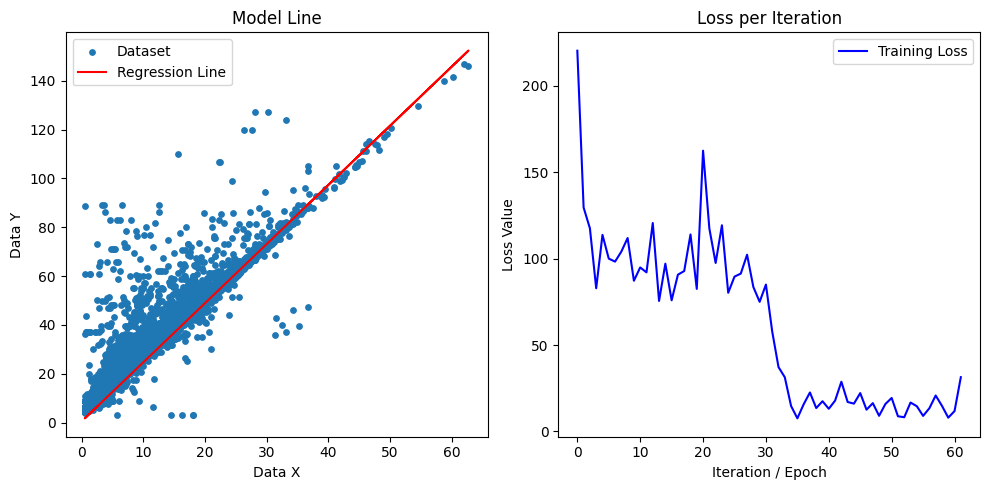

In [6]:
df = pd.read_csv('chicago_taxi_train.csv')

model2 = LinearRegression(batch=500, learning_rate=0.001, epochs=1)

dist = df['TRIP_MILES'].values
fare = df['FARE'].values

testing_setX = dist[-694:-1]
testing_setY = fare[-694:-1]

x = np.delete(dist, slice(-694, -1)) # feature / input
y = np.delete(fare, slice(-694, -1)) # label / data_sample

model2.train(x, y, final_graph=True)

In [7]:
print(model2.get_accuracy(testing_setX, testing_setY))

Accuracy: 94.84 %
